<a href="https://www.kaggle.com/code/sonawanelalitsunil/cve-2024-exploits-security-metrics-ml-95-82?scriptVersionId=230633911" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cve-2024-database-exploits-cvss-os/nvd_vulnerabilities_with_os.csv


## Title: CVE 2024 Database: Exploits, CVSS Scores & Affected OS

### Description: A comprehensive database of 2024 CVEs, detailing exploits, CVSS severity scores, and affected operating systems for quick vulnerability assessment.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/cve-2024-database-exploits-cvss-os/nvd_vulnerabilities_with_os.csv')

In [3]:
df.head()

,CVE ID,Description,CVSS Score,Attack Vector,Affected OS
0,CVE-2024-21732,FlyCms through abbaa5a allows XSS via the perm...,6.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:C/C:L/I:L/A:N,NaN
1,CVE-2023-5877,The affiliate-toolkit WordPress plugin before ...,9.8,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,NaN
2,CVE-2023-6000,The Popup Builder WordPress plugin before 4.2....,6.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:C/C:L/I:L/A:N,NaN
3,CVE-2023-6037,The WP TripAdvisor Review Slider WordPress plu...,4.8,CVSS:3.1/AV:N/AC:L/PR:H/UI:R/S:C/C:L/I:L/A:N,NaN
4,CVE-2023-6064,The PayHere Payment Gateway WordPress plugin b...,7.5,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,NaN


In [4]:
df.tail()

,CVE ID,Description,CVSS Score,Attack Vector,Affected OS
1309,CVE-2024-0557,"A vulnerability, which was classified as probl...",2.4,CVSS:3.1/AV:N/AC:L/PR:H/UI:R/S:U/C:N/I:L/A:N,NaN
1310,CVE-2024-0558,A vulnerability has been found in DedeBIZ 6.3....,4.7,CVSS:3.1/AV:N/AC:L/PR:H/UI:N/S:U/C:L/I:L/A:L,NaN
1311,CVE-2024-0562,A use-after-free flaw was found in the Linux K...,7.8,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,"Redhat Enterprise Linux 9.0, Redhat Enterprise..."
1312,CVE-2024-0565,An out-of-bounds memory read flaw was found in...,6.8,CVSS:3.1/AV:A/AC:H/PR:L/UI:R/S:U/C:H/I:H/A:H,"Linux Linux Kernel, Linux Linux Kernel 6.7"
1313,CVE-2023-7206,\nIn Horner Automation Cscape versions 9.90 SP...,7.8,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:H/I:H/A:H,NaN


In [5]:
df.describe()

,CVSS Score
count,1314.000000
mean,6.789650
std,1.791934
min,2.200000
25%,5.500000
50%,6.700000
75%,7.800000
max,10.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1314 entries, 0 to 1313
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CVE ID         1314 non-null   object 
 1   Description    1314 non-null   object 
 2   CVSS Score     1314 non-null   float64
 3   Attack Vector  1314 non-null   object 
 4   Affected OS    431 non-null    object 
dtypes: float64(1), object(4)
memory usage: 51.5+ KB


In [7]:
df.isnull().sum()

CVE ID             0
Description        0
CVSS Score         0
Attack Vector      0
Affected OS      883
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

CVE ID            object
Description       object
CVSS Score       float64
Attack Vector     object
Affected OS       object
dtype: object

In [10]:
df.shape

(1314, 5)

In [11]:
df.columns

Index(['CVE ID', 'Description', 'CVSS Score', 'Attack Vector', 'Affected OS'], dtype='object')

## Data visualizations

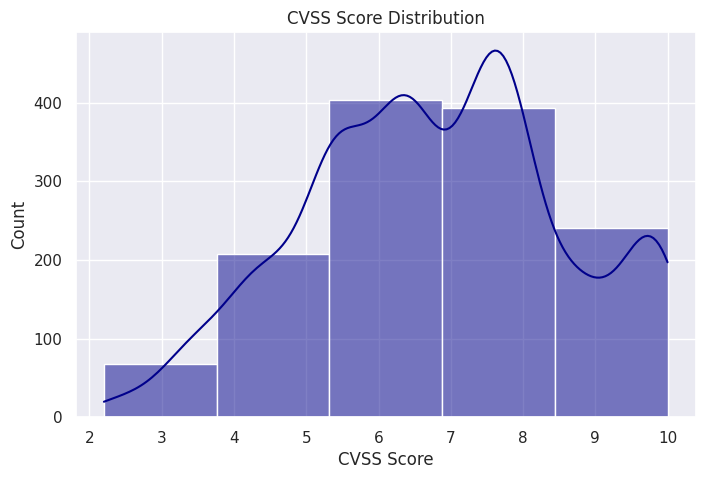

In [12]:
# Set visualization style
sns.set(style="darkgrid", palette="deep")

# CVSS Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['CVSS Score'], bins=5, kde=True, color='darkblue')
plt.title("CVSS Score Distribution")
plt.xlabel("CVSS Score")
plt.ylabel("Count")
plt.show()

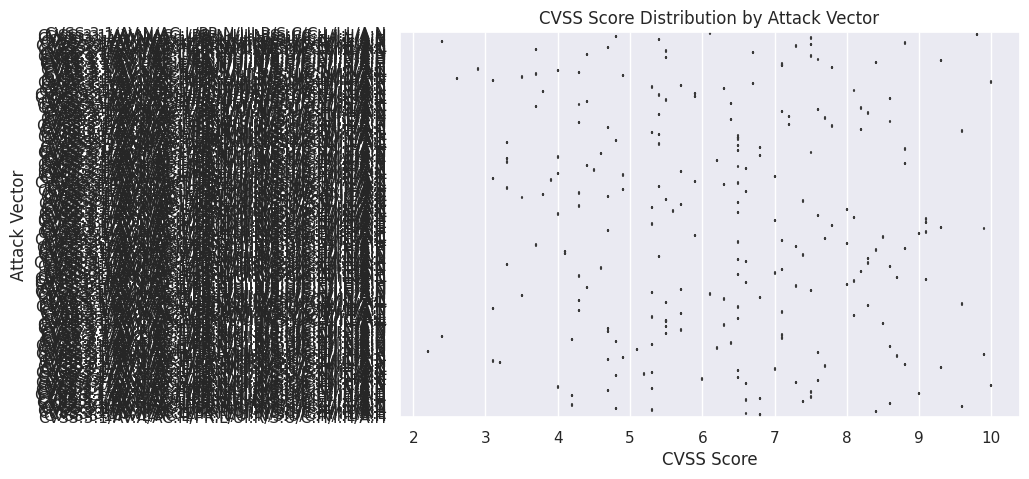

In [13]:
# CVSS Score by Attack Vector
plt.figure(figsize=(8,5))
sns.boxplot(x=df['CVSS Score'], y=df['Attack Vector'], palette="coolwarm")
plt.title("CVSS Score Distribution by Attack Vector")
plt.xlabel("CVSS Score")
plt.ylabel("Attack Vector")
plt.show()

## Predictive modeling

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error

In [15]:
le = LabelEncoder()
df['Attack Vector'] = le.fit_transform(df['Attack Vector'])
df['Affected OS'] = le.fit_transform(df['Affected OS'])


In [16]:
# Define features and target
X = df[['Attack Vector', 'Affected OS']]
y = df['CVSS Score']

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Support Vector Regressor": SVR()
}

In [20]:
# Train and evaluate regressors
regression_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    regression_results[name] = mse * 100
    print(f"{name}: MSE = {mse * 100:.2f}%")

# Convert CVSS Score to classification problem
threshold = 7.0
df['CVSS Category'] = (df['CVSS Score'] >= threshold).astype(int)
y_class = df['CVSS Category']
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

Linear Regression: MSE = 324.52%
Decision Tree Regressor: MSE = 35.63%
Random Forest Regressor: MSE = 29.90%
Support Vector Regressor: MSE = 276.35%


In [21]:
# Initialize classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "Support Vector Classifier": SVC()
}

In [22]:
# Train and evaluate classifiers
classification_results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    classification_results[name] = acc * 100
    print(f"{name}: Accuracy = {acc * 100:.2f}%")

Logistic Regression: Accuracy = 49.81%
Decision Tree Classifier: Accuracy = 95.44%
Random Forest Classifier: Accuracy = 95.44%
Support Vector Classifier: Accuracy = 67.30%


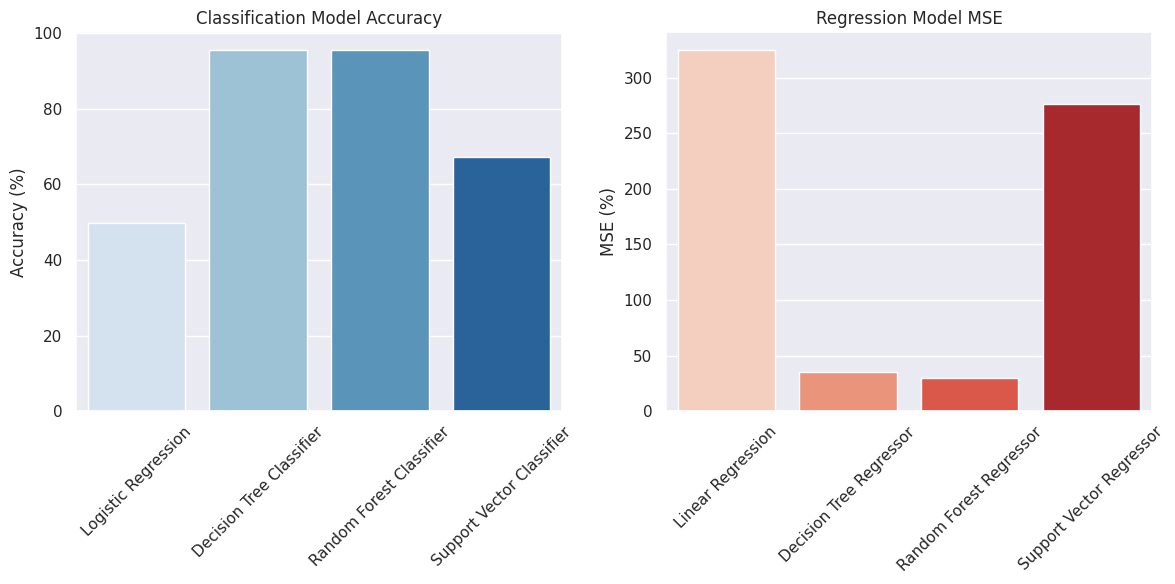

In [23]:
# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=list(classification_results.keys()), y=list(classification_results.values()), palette='Blues')
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.title("Classification Model Accuracy")

plt.subplot(1, 2, 2)
sns.barplot(x=list(regression_results.keys()), y=list(regression_results.values()), palette='Reds')
plt.ylabel("MSE (%)")
plt.xticks(rotation=45)
plt.title("Regression Model MSE")

plt.tight_layout()
plt.show()

### Thank you..pls upvote!!!!